<a href="https://colab.research.google.com/github/Donghwan814/2026_BigDataComputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C(20211125_%EA%B9%80%EB%8F%99%ED%99%98).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 (20211125 김동환)

## 1. 과제 개요
웹상의 기상 데이터를 수집하고, 기계학습이 가능한 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 **개별 함수 단위**로 구현한다.

## 2. 데이터 소스
- URL : `https://github.com/dongupak/DataML/raw/main/csv/weather.csv`
- 주요 컬럼 : **지점, 일시, 평균기온, 최대풍속, 평균풍속**

## 3. 노트북 구성 (평가 기준에 맞춘 섹션 구분)
0. 환경 설정 (한글 폰트 / 라이브러리 import)
1. **모듈화 설계** : 데이터 로드 + 컬럼 점검 함수
2. **데이터 정규화** : Min-Max Scaling 함수
3. **시계열 핸들링** : 날짜 변환, 인덱스 설정, 7일 이동평균
4. **데이터 재구조화** : `groupby` + `pivot_table`
5. **시각화**
6. **엑셀 내보내기 (To Excel)**
7. **`main()` 함수에서 전체 제어**



## 환경 설정 (Colab 한글 폰트 + 라이브러리)

In [21]:
# ========== 0-1. 라이브러리 import ==========
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# ========== 0-2. 환경 설정 (경고 차단 및 한글 폰트) ==========
warnings.filterwarnings('ignore')

# Colab에 나눔폰트 설치
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if not os.path.exists(font_path):
    !sudo apt-get install -y fonts-nanum > /dev/null

# matplotlib 폰트 매니저에 직접 등록 (캐시 갱신보다 확실한 방법)
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()  # 'NanumBarunGothic'

# matplotlib 전역 설정
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# seaborn도 같은 폰트 쓰도록
sns.set_theme(font=font_name, rc={'axes.unicode_minus': False})

print('한글 폰트 설정 완료 :', font_name)

한글 폰트 설정 완료 : NanumBarunGothic


## 1. 모듈화 설계 — 데이터 로드 & 컬럼 점검
데이터 소스에서 CSV를 읽어오고, **주요 컬럼**('일시, 평균기온, 최대풍속, 평균풍속`)이 모두 들어 있는지 확인한다.

In [14]:
# 데이터 소스 URL과 점검할 주요 컬럼 목록 (전역 상수)
DATA_URL = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'
REQUIRED_COLUMNS = ['일시', '평균기온', '최대풍속', '평균풍속'] # csv 파일에서는 지점 컬럼 존재하지 않아 제외


def load_data(url: str = DATA_URL) -> pd.DataFrame:
    """웹 CSV 데이터를 읽어와 DataFrame으로 반환."""
    df = pd.read_csv(url, encoding = 'cp949')
    print(f'[load_data] 데이터 shape = {df.shape}')
    print(f'[load_data] 전체 컬럼   = {list(df.columns)}')
    return df


def check_columns(df: pd.DataFrame, required: list = REQUIRED_COLUMNS) -> None:
    """과제에서 요구하는 주요 컬럼이 모두 있는지 검증."""
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'필수 컬럼 누락: {missing}')
    print(f'[check_columns] 주요 컬럼 모두 존재 → {required}')

## 2. 데이터 정규화 — Min-Max Scaling
수치형 컬럼을 `(x - min) / (max - min)` 공식으로 0~1 사이로 변환.

In [15]:
def min_max_scale(series: pd.Series) -> pd.Series:
    """단일 Series를 Min-Max 정규화 (결과 범위 0~1)."""
    s_min, s_max = series.min(), series.max()
    # 분모 0 (상수 컬럼) 예외 방지
    if s_max == s_min:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)


def add_scaled_column(df: pd.DataFrame, col: str = '평균기온') -> pd.DataFrame:
    """`col` 컬럼을 Min-Max 정규화한 새 컬럼 `<col>_scaled`를 추가."""
    df = df.copy()
    df[f'{col}_scaled'] = min_max_scale(df[col])
    return df

## 3. 시계열 핸들링 — 날짜 변환 / 인덱스 설정 / 7일 이동평균

In [16]:
def get_season(month: int) -> str:
    """월 → 한국식 4계절 문자열로 변환."""
    if month in (3, 4, 5):
        return '봄'
    elif month in (6, 7, 8):
        return '여름'
    elif month in (9, 10, 11):
        return '가을'
    else:  # 12, 1, 2
        return '겨울'


def to_timeseries(df: pd.DataFrame) -> pd.DataFrame:
    """'일시' 컬럼을 datetime으로 변환하고 인덱스로 설정.
    추가로 분석에 쓸 연도/월/계절 파생 컬럼을 만든다."""
    df = df.copy()

    # 날짜 변환 + 결측치 제거
    df['일시'] = pd.to_datetime(df['일시'])
    df = df.dropna(subset=['평균기온', '최대풍속', '평균풍속'])

    # 파생 컬럼 (groupby/pivot_table용)
    df['연도'] = df['일시'].dt.year
    df['월']   = df['일시'].dt.month
    df['계절'] = df['월'].apply(get_season)

    # 시계열 인덱스 설정
    df = df.set_index('일시').sort_index()
    return df


def add_moving_average(df: pd.DataFrame, col: str = '평균기온', window: int = 7) -> pd.DataFrame:
    """`col`의 N일 이동평균(rolling mean) 컬럼을 추가."""
    df = df.copy()
    df[f'{col}_MA{window}'] = df[col].rolling(window=window, min_periods=1).mean()
    return df

## 4. 데이터 재구조화 — `groupby` & `pivot_table`

In [17]:
def make_seasonal_stats(df: pd.DataFrame) -> pd.DataFrame:
    """groupby로 계절별 평균기온·최대풍속·평균풍속의 mean/std/max/min 산출."""
    stats = (
        df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']]
          .agg(['mean', 'std', 'max', 'min'])
    )
    # 계절 순서 정렬 (봄→여름→가을→겨울)
    stats = stats.reindex(['봄', '여름', '가을', '겨울'])
    return stats.round(2)


def make_yearly_pivot(df: pd.DataFrame) -> pd.DataFrame:
    """pivot_table로 연도(행) × 계절(열) 평균기온 표 생성."""
    pivot = pd.pivot_table(
        df,
        values='평균기온',
        index='연도',
        columns='계절',
        aggfunc='mean'
    )
    return pivot.round(2)

## 5. 시각화

In [18]:
def plot_timeseries_and_box(df: pd.DataFrame):
    """Figure 1 : 시계열+이동평균 / 계절별 박스플롯."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # (1) 시계열 그래프 — 원본은 회색, 7일 이동평균은 빨강
    axes[0].plot(df.index, df['평균기온'], color='lightgray', label='원본')
    axes[0].plot(df.index, df['평균기온_MA7'], color='red', label='7일 이동평균')
    axes[0].set_title('기온 시계열 변동 및 추세', fontproperties=font_prop)
    axes[0].legend(loc='lower left', prop=font_prop)

    # (2) 계절별 박스플롯 — 계절 순서 봄→여름→가을→겨울
    sns.boxplot(
        data=df, x='계절', y='평균기온',
        order=['봄', '여름', '가을', '겨울'],
        ax=axes[1]
    )
    axes[1].set_title('계절별 기온 분포', fontproperties=font_prop)
    axes[1].set_xlabel('계절', fontproperties=font_prop)
    axes[1].set_ylabel('평균기온', fontproperties=font_prop)
    for label in axes[1].get_xticklabels():
        label.set_fontproperties(font_prop)

    plt.tight_layout()
    plt.show()


def plot_hist_and_heatmap(df: pd.DataFrame, pivot: pd.DataFrame):
    """Figure 2 : 정규화 히스토그램+KDE / 연도×계절 히트맵."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # (3) Min-Max 정규화한 평균기온 분포 (히스토그램 + KDE)
    sns.histplot(
        df['평균기온_scaled'], bins=20, kde=True,
        color='green', ax=axes[0]
    )
    axes[0].set_title('정규화된 기온 데이터 분포 (Min-Max Scaled)', fontproperties=font_prop)
    axes[0].set_xlabel('평균기온_scaled', fontproperties=font_prop)
    axes[0].set_ylabel('Count')

    # (4) 연도×계절 평균기온 히트맵
    sns.heatmap(
        pivot, annot=True, fmt='.1f',
        cmap='coolwarm', ax=axes[1]
    )
    axes[1].set_title('연도별/계절별 기온 히트맵', fontproperties=font_prop)
    axes[1].set_xlabel('계절', fontproperties=font_prop)
    axes[1].set_ylabel('Year')
    for label in axes[1].get_xticklabels():
        label.set_fontproperties(font_prop)

    plt.tight_layout()
    plt.show()

## 6. 엑셀 내보내기 (To Excel)
한 파일(`weather_analysis_report.xlsx`)에 3개 시트로 분리 저장한다.
- `preprocessed`   : 전처리 데이터(시계열 인덱스 + 정규화/이동평균 컬럼 포함)
- `seasonal_stats` : 계절별 통계
- `yearly_pivot`   : 연도×계절 평균기온 피벗 테이블

In [19]:
def save_to_excel(df_pre: pd.DataFrame,
                  seasonal: pd.DataFrame,
                  pivot: pd.DataFrame,
                  filename: str = 'weather_analysis_report.xlsx') -> None:
    """전처리 데이터/계절별 통계/연도별 피벗 테이블을 별도 시트에 저장."""
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df_pre.to_excel(writer, sheet_name='preprocessed')
        seasonal.to_excel(writer, sheet_name='seasonal_stats')
        pivot.to_excel(writer, sheet_name='yearly_pivot')
    print(f'[save_to_excel] {filename} 저장 완료 (3개 시트)')

## 7. main() — 전체 파이프라인 제어
위에서 정의한 함수들을 순서대로 호출하기만 하면 분석이 끝나도록 구성.

[load_data] 데이터 shape = (3653, 4)
[load_data] 전체 컬럼   = ['일시', '평균기온', '최대풍속', '평균풍속']
[check_columns] 주요 컬럼 모두 존재 → ['일시', '평균기온', '최대풍속', '평균풍속']

=== 계절별 통계 (groupby) ===
     평균기온                    최대풍속                   평균풍속                 
     mean   std   max   min  mean   std   max  min  mean   std   max  min
계절                                                                       
봄   11.30  5.59  26.6  -2.7  8.89  3.03  21.6  2.2  4.41  1.83  12.1  0.8
여름  22.60  3.36  31.3  13.4  7.04  2.95  25.3  2.3  3.65  1.98  14.9  0.2
가을  15.20  5.15  27.2  -0.3  7.56  3.13  26.0  2.0  3.85  2.00  12.7  0.3
겨울   2.51  3.64  15.3  -9.0  8.14  2.67  22.2  2.3  3.84  1.63  11.6  0.7

=== 연도×계절 평균기온 (pivot_table) ===
계절       가을    겨울      봄     여름
연도                             
2010  15.37  4.18    NaN  25.92
2011  15.53  1.29   9.16  22.13
2012  14.46  0.53  10.24  22.22
2013  15.23  1.74  10.32  23.67
2014  15.42  1.85  11.91  21.99
2015  15.05  3.45  11.98  22.05
2016  15.02  3.09 

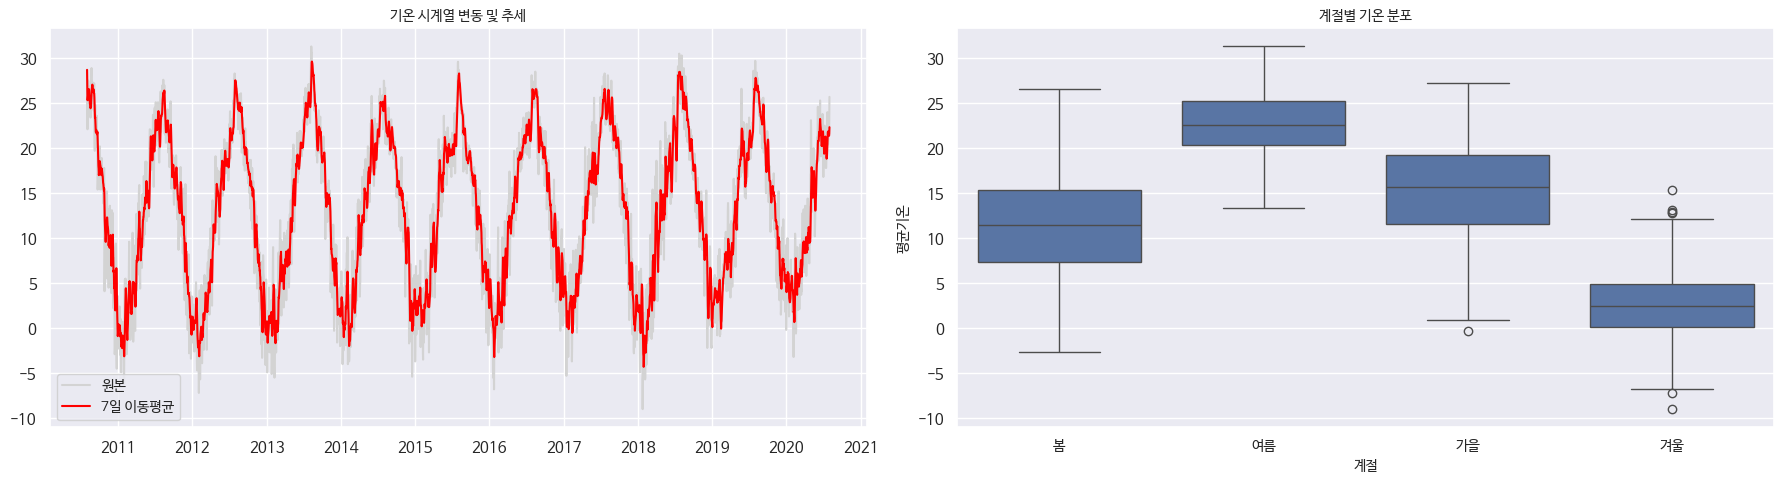

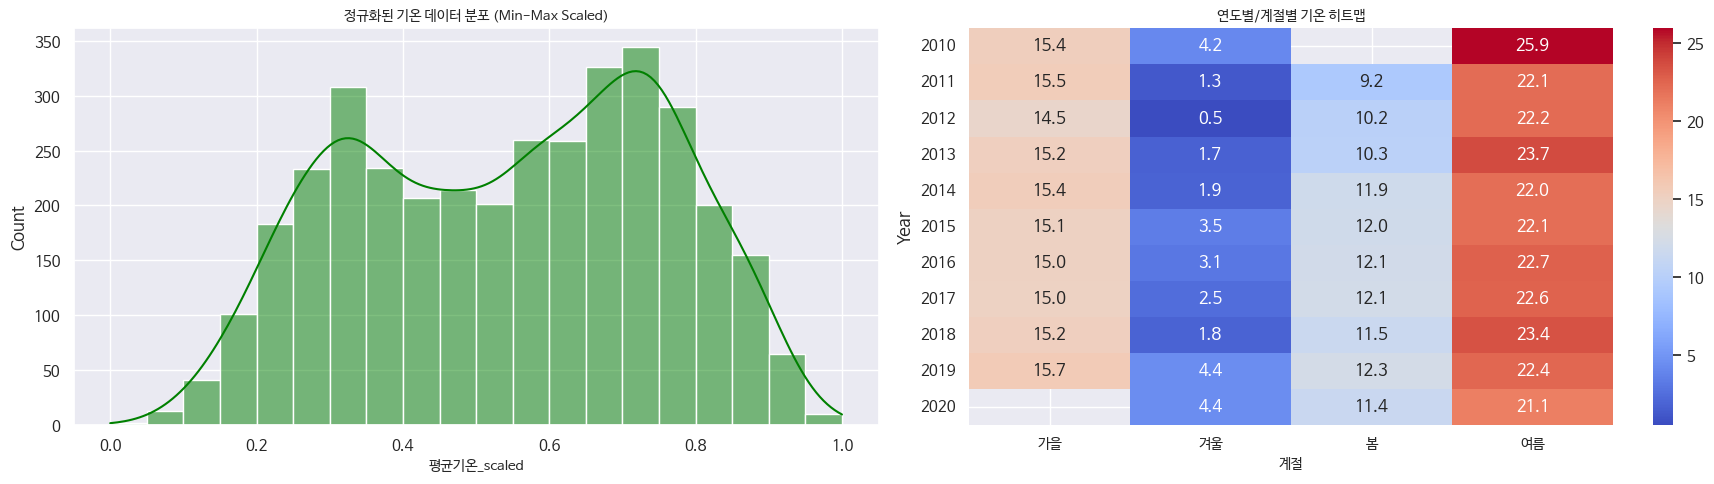

[save_to_excel] weather_analysis_report.xlsx 저장 완료 (3개 시트)


In [22]:
def main():
    # [1] 모듈화 설계 - 데이터 로드 & 컬럼 점검
    df_raw = load_data(DATA_URL)
    check_columns(df_raw, REQUIRED_COLUMNS)

    # [2] 시계열 핸들링 - 날짜 변환 / 인덱스 / 파생 컬럼
    df = to_timeseries(df_raw)

    # [3] 데이터 정규화 - Min-Max Scaling
    df = add_scaled_column(df, col='평균기온')

    # [4] 시계열 핸들링 - 7일 이동평균 추세선
    df = add_moving_average(df, col='평균기온', window=7)

    # [5] 데이터 재구조화 - groupby & pivot_table
    seasonal_stats = make_seasonal_stats(df)
    yearly_pivot   = make_yearly_pivot(df)

    print('\n=== 계절별 통계 (groupby) ===')
    print(seasonal_stats)
    print('\n=== 연도×계절 평균기온 (pivot_table) ===')
    print(yearly_pivot)

    # [6] 시각화 - 과제 개요의 4개 그래프
    plot_timeseries_and_box(df)
    plot_hist_and_heatmap(df, yearly_pivot)

    # [7] 엑셀 내보내기 - 한 파일에 3개 시트
    save_to_excel(df, seasonal_stats, yearly_pivot,
                  filename='weather_analysis_report.xlsx')


# 노트북에서 바로 실행
main()